# Goals
The goals of this analysis are to determine the extent and scale of batch effects present in the experiment.

This experiment consisted of 2 technical replicates. All viral particles were produced in one well (e.g. 1 6-well per virus particle). After production, viruses were rearranged into different plate layouts so that viruses were in different wells of the 384 well plate. I did not fully randomize the wells because I randomized by rows and columns so there is still some confounding.

# Import

In [ ]:
# Repo-relative paths: inputs are read from imports_stable/, outputs are written to analysis_outs/
import os
from pathlib import Path
_here = Path.cwd().resolve()
REPO_DIR = str(next(p for p in [_here, *_here.parents] if (p / "imports_stable").is_dir()))
IMPORTS_DIR = f"{REPO_DIR}/imports_stable"
OUTS_DIR = f"{REPO_DIR}/analysis_outs/02_combinatorial_screen_signalseq_SIG13"
for _d in ["plots/qc", "replicate_corr"]:
    os.makedirs(f"{OUTS_DIR}/{_d}", exist_ok=True)

In [1]:
import numpy as np
import scanpy as sc
import pandas as pd

import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype']  = 42
plt.rcParams['text.usetex']  = False

import sys
sys.path.insert(0, f"{REPO_DIR}/functions")
import scanpy_custom as scc
import perturbseq as ps

%load_ext autoreload
%autoreload 2

In [2]:
adata = sc.read_h5ad(IMPORTS_DIR + "/SIG13/scanpy_outs/SIG13_doublets_DSB7.h5ad")
# add replicate + lane column
adata.obs['replicate_lane'] = adata.obs['replicate'].astype(str) + "_" + adata.obs['lane'].astype(str)
adata.obs['replicate_feature_call_DSB7'] = adata.obs['replicate'].astype(str) + "_" + adata.obs['feature_call_DSB7'].astype(str)
adata.obs['replicate_ligand_call_DSB7'] = adata.obs['replicate'].astype(str) + "_" + adata.obs['ligand_call_DSB7'].astype(str)

In [4]:
# import interaction coeff and classified lfc values
interCoeff = pd.read_csv(IMPORTS_DIR + "/SIG13/analysis_outs/glmGamPoi/glmGamPoi_interaction_coefficients_0.2filter.csv")
interScored = pd.read_csv(IMPORTS_DIR + "/SIG13/analysis_outs/glmGamPoi/interactions_scored_v3_glmGamPoi_0.2filter_sig.csv")
interLfcReplicates = pd.read_csv(IMPORTS_DIR + "/SIG13/analysis_outs/glmGamPoi/glmGamPoi_interaction_lfc_independent_replicates_0.2filter.csv")

In [5]:
# import single lfc values
singleCoeff = pd.read_csv(IMPORTS_DIR + "/SIG13/analysis_outs/glmGamPoi/glmGamPoi_singleTerm_coefficients_0.2filter.csv")
singleLfc = pd.read_csv(IMPORTS_DIR + "/SIG13/analysis_outs/glmGamPoi/glmGamPoi_singleTerm_lfc_0.2filter.csv")
singleLfcReplicates = pd.read_csv(IMPORTS_DIR + "/SIG13/analysis_outs/glmGamPoi/glmGamPoi_singleTerm_lfc_independent_replicates_0.2filter.csv")

# Replicate Correlations

## Interaction Effect Consistency

### Interaction LFC Correlation
Here, I will calculate the correlation between interaction LFCs between the two replicates for each ligand individually, only using genes that are significant in one of the replicates.

In [6]:
def pairwise_cor_inter(interLfc: pd.DataFrame,
                       pval_cutoff: float) -> pd.DataFrame:
    """
    For each interaction, compute Pearson correlation of lfc_rep1 vs lfc_rep2. Correlations
    are calculated using genes that are significant in at least one replicate.
    
    Returns a DataFrame with columns: interaction, pearson_corr, num_shared_genes.
    """
    # 1) one‐time pivot
    wide = (
        interLfc
        .set_index(['interaction','name','replicate'])[['lfc','adj_pval']]
        .unstack('replicate')
    )
    wide.columns = [f"{var}_{rep}" for var,rep in wide.columns]
    wide = wide.reset_index()

    # 2) count genes significant in *both* reps
    both_sig = (wide['adj_pval_rep1'] < pval_cutoff) & (wide['adj_pval_rep2'] < pval_cutoff)
    gene_num = (
        wide.loc[both_sig]
        .groupby('interaction')
        .size()
        .reset_index(name='num_shared_genes')
    )

    # 3) keep genes significant in *either* rep, drop missing LFCs
    either_sig = ((wide['adj_pval_rep1'] < pval_cutoff) |
                  (wide['adj_pval_rep2'] < pval_cutoff))
    wide = wide.loc[either_sig].dropna(subset=['lfc_rep1','lfc_rep2'])

    # 4) compute Pearson *only* on the two LFC columns
    corrs = (
        wide
        .groupby('interaction')[['lfc_rep1','lfc_rep2']]
        .apply(lambda df: df['lfc_rep1'].corr(df['lfc_rep2']))
        .reset_index(name='pearson_corr')
    )

    # 5) re‐attach the gene counts
    return corrs.merge(gene_num, on='interaction', how='left')

In [7]:
# get correlation between replicates
interRepCor = pairwise_cor_inter(interLfcReplicates, pval_cutoff=0.1)
# replace NaNs with 0
interRepCor['num_shared_genes'] = interRepCor['num_shared_genes'].fillna(0)
interRepCor['num_shared_genes_log10'] = np.log10(interRepCor['num_shared_genes'])

# calculate number of significant gene interactions per interaction with bulk GLM data
interScoredSummary = (interScored
                      .query('adj_pval_interaction < 0.1')
                      .groupby('interaction')
                      .size()
                      .reset_index(name='num_genes_interacting'))

# merge with interaction coefficients
interRepCor = interRepCor.merge(interScoredSummary, on='interaction', how='left')
# replace NaNs with 0
interRepCor['num_genes_interacting'] = interRepCor['num_genes_interacting'].fillna(0)
interRepCor['num_genes_interacting_log10'] = np.log10(interRepCor['num_genes_interacting'])

/data1/rudenska/EYW/mamba_envs/scanpy_standard2/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3015: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/data1/rudenska/EYW/mamba_envs/scanpy_standard2/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/data1/rudenska/EYW/mamba_envs/scanpy_standard2/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)
/data1/rudenska/EYW/mamba_envs/scanpy_standard2/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/data1/rudenska/EYW/mamba_envs/scanpy_standard2/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc,

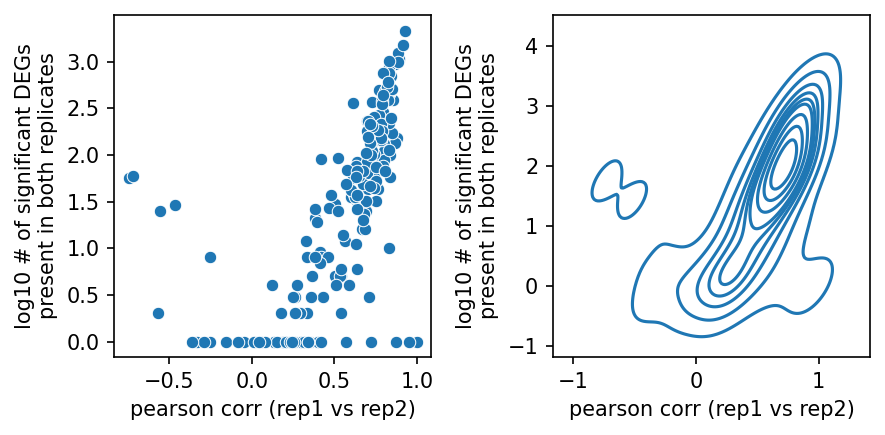

In [8]:
# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3))

# First plot - scatter plot
sns.scatterplot(
    data=interRepCor,
    x='pearson_corr',
    y='num_shared_genes_log10',
    ax=ax1
)
ax1.set_ylabel("log10 # of significant DEGs\npresent in both replicates")
ax1.set_xlabel("pearson corr (rep1 vs rep2)")

# Second plot - KDE plot
sns.kdeplot(
    data=interRepCor,
    x='pearson_corr',
    y='num_shared_genes_log10',
    ax=ax2
)
ax2.set_ylabel("log10 # of significant DEGs\npresent in both replicates")
ax2.set_xlabel("pearson corr (rep1 vs rep2)")

plt.tight_layout()
plt.show()

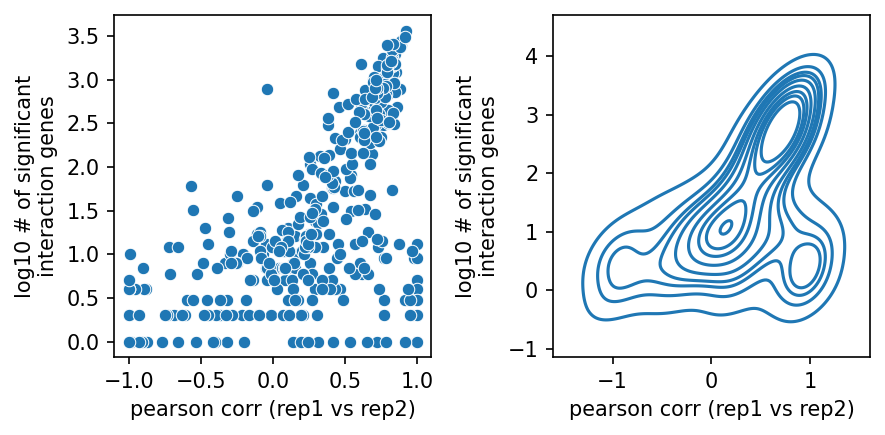

In [9]:
# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3))

# First plot - scatter plot
sns.scatterplot(
    data=interRepCor,
    x='pearson_corr',
    y='num_genes_interacting_log10',
    ax=ax1
)
ax1.set_ylabel("log10 # of significant\ninteraction genes")
ax1.set_xlabel("pearson corr (rep1 vs rep2)")

# Second plot - KDE plot
sns.kdeplot(
    data=interRepCor,
    x='pearson_corr',
    y='num_genes_interacting_log10',
    ax=ax2
)
ax2.set_ylabel("log10 # of significant\ninteraction genes")
ax2.set_xlabel("pearson corr (rep1 vs rep2)")

plt.tight_layout()
plt.show()

## Overall DEG Consistency
Instead of looking at the effects in the interaction lfc specifically, here I will just look at consistency in overall DEGs from comparing each ligand condition to control separately.

### LFC Correlation
Here, I will calculate the correlation between interaction LFCs between the two replicates for each ligand individually, only using genes that are significant in either one or both of the replicates.

In [10]:
def pairwise_cor_single(singleLfc: pd.DataFrame,
                       pval_cutoff: float) -> pd.DataFrame:
    """
    For each condition, compute Pearson correlation of lfc_rep1 vs lfc_rep2. Correlations
    are calculated using genes that are significant in at least one replicate.
    
    Returns a DataFrame with columns: condition, pearson_corr, num_shared_genes.
    """
    # 1) one‐time pivot
    wide = (
        singleLfc
        .set_index(['condition','name','replicate'])[['lfc','adj_pval']]
        .unstack('replicate')
    )
    wide.columns = [f"{var}_{rep}" for var,rep in wide.columns]
    wide = wide.reset_index()

    # 2) count genes significant in *both* reps
    both_sig = (wide['adj_pval_rep1'] < pval_cutoff) & (wide['adj_pval_rep2'] < pval_cutoff)
    gene_num = (
        wide.loc[both_sig]
        .groupby('condition')
        .size()
        .reset_index(name='num_shared_genes')
    )

    # 3) keep genes significant in *either* rep, drop missing LFCs
    either_sig = ((wide['adj_pval_rep1'] < pval_cutoff) |
                  (wide['adj_pval_rep2'] < pval_cutoff))
    wide = wide.loc[either_sig].dropna(subset=['lfc_rep1','lfc_rep2'])

    # 4) compute Pearson *only* on the two LFC columns
    corrs = (
        wide
        .groupby('condition')[['lfc_rep1','lfc_rep2']]
        .apply(lambda df: df['lfc_rep1'].corr(df['lfc_rep2']))
        .reset_index(name='pearson_corr')
    )

    # 5) re‐attach the gene counts
    return corrs.merge(gene_num, on='condition', how='left')

In [11]:
# get correlation between replicates for single ligand effects
singleRepCor = pairwise_cor_single(singleLfcReplicates, pval_cutoff=0.1)
# replace NaNs with 0
singleRepCor['num_shared_genes'] = singleRepCor['num_shared_genes'].fillna(0)
singleRepCor['pearson_corr'] = singleRepCor['pearson_corr'].fillna(0)
singleRepCor['num_shared_genes_log10'] = np.log10(singleRepCor['num_shared_genes'] + 1)

singleScoredSummary = (singleLfc
                       .query('adj_pval < 0.1')
                       .groupby('condition')
                       .size()
                       .reset_index(name='num_degs'))

# merge with single ligand correlation results
singleRepCor = singleRepCor.merge(singleScoredSummary, on='condition', how='left')
# replace NaNs with 0
singleRepCor['num_degs'] = singleRepCor['num_degs'].fillna(0)
singleRepCor['num_degs_log10'] = np.log10(singleRepCor['num_degs'] + 1)

/data1/rudenska/EYW/mamba_envs/scanpy_standard2/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3015: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/data1/rudenska/EYW/mamba_envs/scanpy_standard2/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/data1/rudenska/EYW/mamba_envs/scanpy_standard2/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


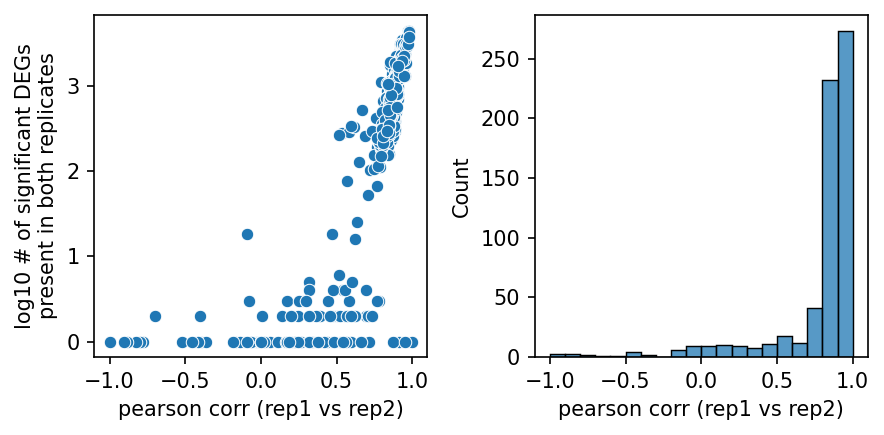

In [12]:
# Create side-by-side plots for single ligand effects
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6,3))

# First plot - scatter plot
sns.scatterplot(
    data=singleRepCor,
    x='pearson_corr',
    y='num_shared_genes_log10',
    ax=ax1
)
ax1.set_ylabel("log10 # of significant DEGs\npresent in both replicates")
ax1.set_xlabel("pearson corr (rep1 vs rep2)")

# Second plot - histogram of correlations
sns.histplot(
    data=singleRepCor,
    x='pearson_corr',
    bins=20,
    ax=ax2
)
ax2.set_xlabel("pearson corr (rep1 vs rep2)")
ax2.set_ylabel("Count")

plt.tight_layout()
plt.savefig(OUTS_DIR + "/plots/qc/replicate_corr_all_deg.pdf", bbox_inches='tight')
plt.show()

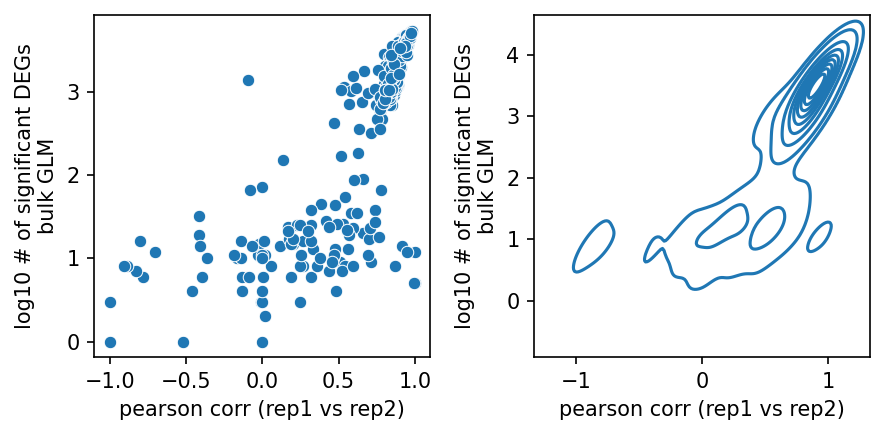

In [13]:
# Create additional plots showing correlation vs number of significant genes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6,3))

# First plot - scatter plot
sns.scatterplot(
    data=singleRepCor,
    x='pearson_corr',
    y='num_degs_log10',
    ax=ax1
)
ax1.set_ylabel("log10 # of significant DEGs\nbulk GLM")
ax1.set_xlabel("pearson corr (rep1 vs rep2)")

sns.kdeplot(
    data=singleRepCor,
    x='pearson_corr',
    y='num_degs_log10',
    ax=ax2
)
ax2.set_ylabel("log10 # of significant DEGs\nbulk GLM")
ax2.set_xlabel("pearson corr (rep1 vs rep2)")
plt.tight_layout()
plt.show()

# Orientation Correlations
Here, we calculate the Pearson correlation between the `A_B` and `B_A`. Both replicates are pooled for these comparisons, so the only difference between the two members of a pair is the orientation. Orientation represents VLP derived from Set A and Set B respectively.

In [14]:
EXCLUDED_LIGANDS = ('TGFB1')

def get_orientation_pairs(conditions, exclude_ligands=EXCLUDED_LIGANDS) -> pd.DataFrame:
    """
    Identify ligand conditions that are present in both linker orientations (A_B and B_A).

    Any condition containing a ligand in `exclude_ligands` is dropped. By default this
    removes the single-ligand linker controls (linker_IL2 / IL2_linker), so only genuine
    two-ligand pairs are compared, and TGFB1.

    `pair` is the orientation-independent key ("_".join(sorted(ligands))) and `orientation`
    is 'orient1' for the alphabetically sorted label and 'orient2' for its reverse.

    Returns a DataFrame with columns: condition, pair, orientation.
    """
    conditions = set(conditions)
    exclude_ligands = set(exclude_ligands)
    rows = []
    for cond in conditions:
        ligands = cond.split('_')
        if len(ligands) != 2:
            continue
        if exclude_ligands.intersection(ligands):
            continue
        reverse = '_'.join(ligands[::-1])
        # skip homodimers (A_A) and conditions only present in one orientation
        if reverse == cond or reverse not in conditions:
            continue
        pair = '_'.join(sorted(ligands))
        rows.append({'condition': cond,
                     'pair': pair,
                     'orientation': 'orient1' if cond == pair else 'orient2'})
    return (pd.DataFrame(rows)
            .sort_values(['pair', 'orientation'])
            .reset_index(drop=True))

In [15]:
def pairwise_cor_orientation(lfc: pd.DataFrame,
                             label_col: str,
                             pval_cutoff: float,
                             lfc_col: str = 'lfc',
                             pval_col: str = 'adj_pval',
                             gene_col: str = 'name') -> pd.DataFrame:
    """
    For each ligand pair present in both linker orientations, compute the Pearson
    correlation of lfc_orient1 vs lfc_orient2. Correlations are calculated using genes
    that are significant in at least one orientation.

    Returns a DataFrame with columns: pair, condition_orient1, condition_orient2,
    pearson_corr, num_genes_correlated, num_shared_genes.
    """
    # 0) restrict to conditions present in both orientations
    pairs = get_orientation_pairs(lfc[label_col].unique()).rename(columns={'condition': label_col})
    df = lfc.merge(pairs, on=label_col, how='inner')

    # 1) one-time pivot, putting the two orientations side by side
    wide = (
        df
        .set_index(['pair', gene_col, 'orientation'])[[lfc_col, pval_col]]
        .unstack('orientation')
    )
    wide.columns = [f"{var}_{orient}" for var, orient in wide.columns]
    wide = wide.reset_index()

    # 2) count genes significant in *both* orientations
    both_sig = ((wide[f'{pval_col}_orient1'] < pval_cutoff) &
                (wide[f'{pval_col}_orient2'] < pval_cutoff))
    gene_num = (
        wide.loc[both_sig]
        .groupby('pair')
        .size()
        .reset_index(name='num_shared_genes')
    )

    # 3) keep genes significant in *either* orientation, drop missing LFCs
    either_sig = ((wide[f'{pval_col}_orient1'] < pval_cutoff) |
                  (wide[f'{pval_col}_orient2'] < pval_cutoff))
    wide = wide.loc[either_sig].dropna(subset=[f'{lfc_col}_orient1', f'{lfc_col}_orient2'])

    # 4) compute Pearson *only* on the two LFC columns
    corrs = (
        wide
        .groupby('pair')[[f'{lfc_col}_orient1', f'{lfc_col}_orient2']]
        .apply(lambda d: d[f'{lfc_col}_orient1'].corr(d[f'{lfc_col}_orient2']))
        .reset_index(name='pearson_corr')
    )

    # number of genes each correlation was actually computed from -- pairs with only a
    # handful of significant genes can give spuriously perfect correlations
    gene_used = (
        wide
        .groupby('pair')
        .size()
        .reset_index(name='num_genes_correlated')
    )

    # 5) re-attach the gene counts and the two condition labels
    labels = (pairs
              .pivot(index='pair', columns='orientation', values=label_col)
              .rename(columns={'orient1': 'condition_orient1',
                               'orient2': 'condition_orient2'})
              .reset_index())

    return (corrs
            .merge(gene_used, on='pair', how='left')
            .merge(gene_num, on='pair', how='left')
            .merge(labels, on='pair', how='left'))

## Interaction LFC Orientation Correlation
Same comparison but on the interaction term (`ligand1:ligand2`). The scored table only contains genes that passed the interaction significance cutoff, so LFCs are taken from the full coefficient table and any gene missing from the scored table is treated as non-significant.

In [16]:
# build a long interaction-LFC table covering *all* genes, with adj_pvals attached
# (interScored only contains significant interaction genes, interCoeff contains all of them)
interLfcAll = (
    interCoeff
    .rename(columns={'genes': 'name', 'ligand1:ligand2': 'lfc'})[['name', 'interaction', 'lfc']]
    .merge(interScored[['name', 'interaction', 'adj_pval_interaction']]
           .rename(columns={'adj_pval_interaction': 'adj_pval'}),
           on=['name', 'interaction'], how='left')
)
# genes absent from the significance-filtered table are non-significant
interLfcAll['adj_pval'] = interLfcAll['adj_pval'].fillna(1.0)

# get correlation between orientations for interaction effects
interOrientCor = pairwise_cor_orientation(interLfcAll, label_col='interaction', pval_cutoff=0.1)
# replace NaNs with 0
interOrientCor['num_shared_genes'] = interOrientCor['num_shared_genes'].fillna(0)
interOrientCor['pearson_corr'] = interOrientCor['pearson_corr'].fillna(0)
interOrientCor['num_shared_genes_log10'] = np.log10(interOrientCor['num_shared_genes'] + 1)

# number of significant interaction genes per interaction, averaged over the two orientations
interScoredSummary = (interScored
                      .query('adj_pval_interaction < 0.1')
                      .groupby('interaction')
                      .size()
                      .reset_index(name='num_genes_interacting'))

for orient in ['orient1', 'orient2']:
    interOrientCor = interOrientCor.merge(
        interScoredSummary.rename(columns={'interaction': f'condition_{orient}',
                                           'num_genes_interacting': f'num_genes_interacting_{orient}'}),
        on=f'condition_{orient}', how='left')

interOrientCor[['num_genes_interacting_orient1', 'num_genes_interacting_orient2']] = (
    interOrientCor[['num_genes_interacting_orient1', 'num_genes_interacting_orient2']].fillna(0))
interOrientCor['num_genes_interacting'] = (
    interOrientCor[['num_genes_interacting_orient1', 'num_genes_interacting_orient2']].mean(axis=1))
interOrientCor['num_genes_interacting_log10'] = np.log10(interOrientCor['num_genes_interacting'] + 1)

print(f"{len(interOrientCor)} interactions present in both orientations")
print(interOrientCor['num_genes_correlated'].describe())

55 interactions present in both orientations
count      55.000000
mean      613.836364
std       779.677064
min         1.000000
25%        10.000000
50%       307.000000
75%       951.000000
max      3360.000000
Name: num_genes_correlated, dtype: float64


/data1/rudenska/EYW/mamba_envs/scanpy_standard2/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3015: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/data1/rudenska/EYW/mamba_envs/scanpy_standard2/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/data1/rudenska/EYW/mamba_envs/scanpy_standard2/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:2888: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


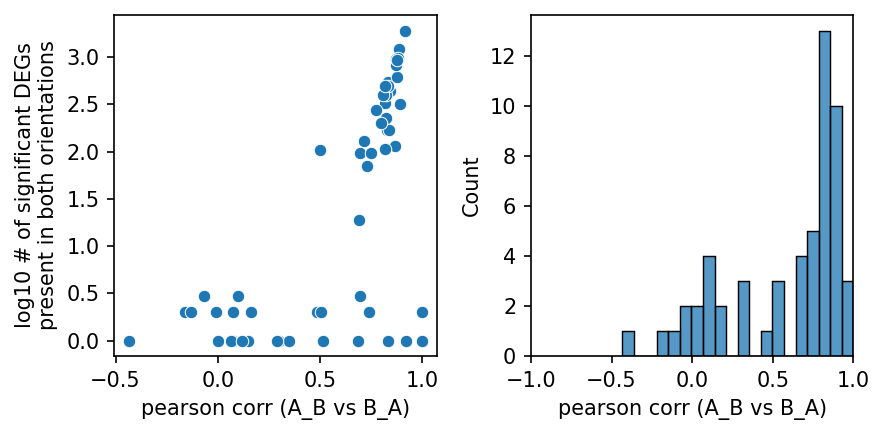

In [23]:
# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3))

# First plot - scatter plot
sns.scatterplot(
    data=interOrientCor,
    x='pearson_corr',
    y='num_shared_genes_log10',
    ax=ax1
)
ax1.set_ylabel("log10 # of significant DEGs\npresent in both orientations")
ax1.set_xlabel("pearson corr (A_B vs B_A)")

# Second plot - histogram of correlations
sns.histplot(
    data=interOrientCor,
    x='pearson_corr',
    bins=20,
    ax=ax2
)
ax2.set_xlim(-1,1)
ax2.set_xlabel("pearson corr (A_B vs B_A)")
ax2.set_ylabel("Count")

plt.tight_layout()
plt.savefig(OUTS_DIR + "/plots/qc/orientation_corr_interaction.pdf", bbox_inches='tight')
plt.show()

## Overall DEG Orientation Correlation
Same comparison but on the overall DEGs from comparing each ligand condition to control separately (single-term GLM LFCs), using genes significant in at least one orientation.

In [18]:
# get correlation between orientations for overall DEG effects
singleOrientCor = pairwise_cor_orientation(singleLfc, label_col='condition', pval_cutoff=0.1)
# replace NaNs with 0
singleOrientCor['num_shared_genes'] = singleOrientCor['num_shared_genes'].fillna(0)
singleOrientCor['pearson_corr'] = singleOrientCor['pearson_corr'].fillna(0)
singleOrientCor['num_shared_genes_log10'] = np.log10(singleOrientCor['num_shared_genes'] + 1)

# number of significant DEGs per condition, averaged over the two orientations
singleScoredSummary = (singleLfc
                       .query('adj_pval < 0.1')
                       .groupby('condition')
                       .size()
                       .reset_index(name='num_degs'))

for orient in ['orient1', 'orient2']:
    singleOrientCor = singleOrientCor.merge(
        singleScoredSummary.rename(columns={'condition': f'condition_{orient}',
                                            'num_degs': f'num_degs_{orient}'}),
        on=f'condition_{orient}', how='left')

singleOrientCor[['num_degs_orient1', 'num_degs_orient2']] = (
    singleOrientCor[['num_degs_orient1', 'num_degs_orient2']].fillna(0))
singleOrientCor['num_degs'] = singleOrientCor[['num_degs_orient1', 'num_degs_orient2']].mean(axis=1)
singleOrientCor['num_degs_log10'] = np.log10(singleOrientCor['num_degs'] + 1)

print(f"{len(singleOrientCor)} ligand pairs present in both orientations")
print(singleOrientCor['num_genes_correlated'].describe())

66 ligand pairs present in both orientations
count      66.000000
mean     3725.393939
std      1478.113360
min        23.000000
25%      2950.500000
50%      4316.500000
75%      4932.250000
max      5542.000000
Name: num_genes_correlated, dtype: float64


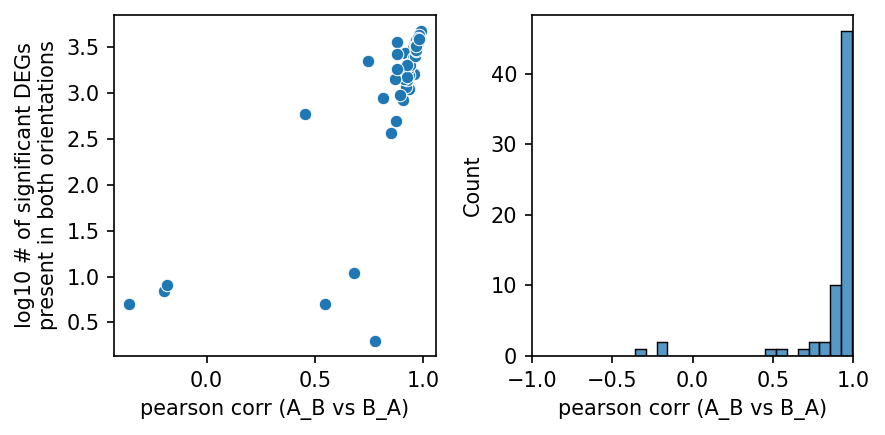

In [22]:
# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3))

# First plot - scatter plot
sns.scatterplot(
    data=singleOrientCor,
    x='pearson_corr',
    y='num_shared_genes_log10',
    ax=ax1
)
ax1.set_ylabel("log10 # of significant DEGs\npresent in both orientations")
ax1.set_xlabel("pearson corr (A_B vs B_A)")

# Second plot - histogram of correlations
sns.histplot(
    data=singleOrientCor,
    x='pearson_corr',
    bins=20,
    ax=ax2
)
ax2.set_xlim(-1,1)
ax2.set_xlabel("pearson corr (A_B vs B_A)")
ax2.set_ylabel("Count")

plt.tight_layout()
plt.savefig(OUTS_DIR + "/plots/qc/orientation_corr_all_deg.pdf", bbox_inches='tight')
plt.show()

## Export Orientation Correlations

In [20]:
# export interaction orientation correlations
interOrientCor.to_csv(OUTS_DIR + "/replicate_corr/orientation_correlation_interactionLfc_0.2filter.csv",
                      index=False)

# export overall DEG orientation correlations
singleOrientCor.to_csv(OUTS_DIR + "/replicate_corr/orientation_correlation_singleLfc_0.2filter.csv",
                       index=False)

## Export Replicate Correlations

In [21]:
# export interaction correlations
interRepCor.to_csv(OUTS_DIR + "/replicate_corr/replicate_correlation_interactionLfc_0.2filter.csv",
                   index=False)

# export single ligand correlations
singleRepCor.to_csv(OUTS_DIR + "/replicate_corr/replicate_correlation_singleLfc_0.2filter.csv",
                   index=False)